# Testing the API

Affichage de 1 image par classe

Collecte d'une image par classe...


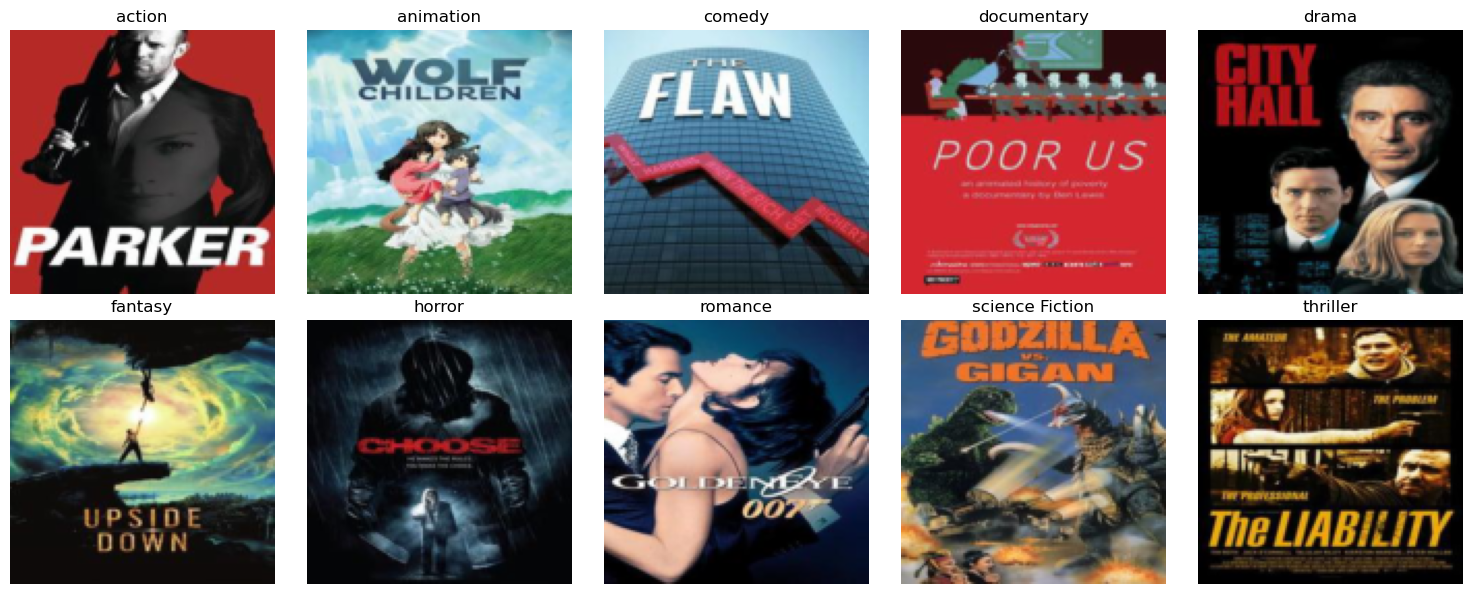

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision.transforms as T
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder



MEAN = (0.5, 0.5, 0.5)
STD = (0.5, 0.5, 0.5)

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

dataset_path = './content/'
full_dataset = ImageFolder(root=dataset_path, transform=transform)


def denormalize_image(tensor):
    inv_normalize = transforms.Normalize(
        mean=[-m/s for m, s in zip(MEAN, STD)],
        std=[1/s for s in STD]
    )
    return inv_normalize(tensor)


def display_one_image_per_class(dataset):
    class_to_image = {}
    print("Collecte d'une image par classe...")

    for img, label in dataset:
        class_name = dataset.classes[label]
        if class_name not in class_to_image:
            class_to_image[class_name] = img
        if len(class_to_image) == len(dataset.classes):
            break

    num_classes = len(class_to_image)

    cols = 5
    rows = int(np.ceil(num_classes / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))

    # --- NORMALISATION DE LA FORME DE AXES ---
    if rows == 1 and cols == 1:
        axes = np.array([axes])
    elif rows == 1:
        axes = np.array(axes)
    else:
        axes = axes.flatten()
    # ------------------------------------------

    for i, (class_name, img_tensor) in enumerate(class_to_image.items()):
        ax = axes[i]

        img = denormalize_image(img_tensor).numpy().transpose(1, 2, 0)
        img = np.clip(img, 0, 1)

        ax.imshow(img)
        ax.set_title(class_name)
        ax.axis('off')

    # Cacher les cases en trop
    for j in range(len(class_to_image), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


display_one_image_per_class(full_dataset)


In [10]:
import requests
import io
from torchvision import transforms

to_pil = transforms.ToPILImage()

for i in range(10):
    image, label = full_dataset[i]
    # Convert image to bytes
    if image.is_cuda:
        image = image.cpu()
        
    
    pil_image = to_pil(image)
    
    # 2. Now the PIL Image object has the .save() method
    img_binary = io.BytesIO()
    # Use the PIL image's save method
    pil_image.save(img_binary, format="PNG")
    # Send request to the API
    response = requests.post("http://0.0.0.0:5075/predict", data=img_binary.getvalue())
    print("Predicted Label:", response.json()["prediction"], "True Label:", label)

Predicted Label: 6 True Label: 0
Predicted Label: 2 True Label: 0
Predicted Label: 2 True Label: 0
Predicted Label: 2 True Label: 0
Predicted Label: 6 True Label: 0
Predicted Label: 6 True Label: 0
Predicted Label: 2 True Label: 0
Predicted Label: 6 True Label: 0
Predicted Label: 2 True Label: 0
Predicted Label: 6 True Label: 0


In [19]:
images = []
labels = []

for i in range(10):
    image, label = full_dataset[i]
    # Convert image to bytes
    if image.is_cuda:
        image = image.cpu()
        
    
    pil_image = to_pil(image)
    
    # 2. Now the PIL Image object has the .save() method
    img_binary = io.BytesIO()
    # Use the PIL image's save method
    pil_image.save(img_binary, format="PNG")
    images.append(('images[]', (f"image_{i}.png", img_binary.getvalue(), 'image/png')))
    labels.append(label)
    # Send request to the API for batch prediction
response = requests.post("http://127.0.0.1:5075/batch_predict", files=images)
predictions = response.json()["predictions"]

for i, (pred, true_label) in enumerate(zip(predictions, labels)):
    print(f"Image {i+1} - Predicted Label:", pred, "| True Label:", true_label)

Image 1 - Predicted Label: 6 | True Label: 0
Image 2 - Predicted Label: 2 | True Label: 0
Image 3 - Predicted Label: 2 | True Label: 0
Image 4 - Predicted Label: 2 | True Label: 0
Image 5 - Predicted Label: 6 | True Label: 0
Image 6 - Predicted Label: 6 | True Label: 0
Image 7 - Predicted Label: 2 | True Label: 0
Image 8 - Predicted Label: 6 | True Label: 0
Image 9 - Predicted Label: 2 | True Label: 0
Image 10 - Predicted Label: 6 | True Label: 0
